In [1]:
import numpy as np

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)

In [2]:
# =============================================================================
# 1. DEFINIZIONE DEL MODELLO ODE CON MEMORIA ED OMEOSTASI
# =============================================================================
def radionuclide_memory_ode(t, y, kin, kout, alpha, gamma, lmbda):
    """
    Sistema ODE per l'uptake di radionuclidi liberi con variabile di memoria C(t) in [0, 1].
    
    Stati:
      y[0] = Am     : Attività nel medium (kBq/mL)
      y[1] = Acell  : Attività cellulare (Bq/cellula)
      y[2] = C      : Capacità di trasporto residua [0, 1]
    """
    Am, Acell, C = y
    
    dAm    = - lmbda * Am - kin * C * Am + kout * Acell
    dAcell = - lmbda * Acell + kin * C * Am - kout * Acell
    dC     = - alpha * C * Acell + gamma * (1.0 - C)
    
    return [dAm, dAcell, dC]

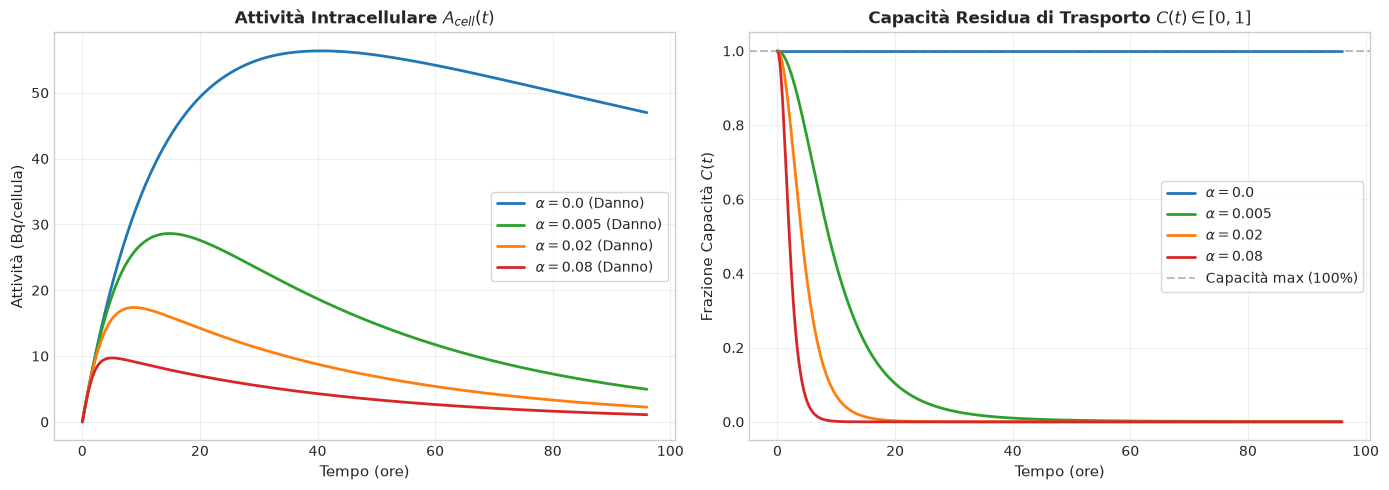

In [8]:
# =============================================================================
# 2. STUDIO DELLA SENSIBILITÀ AL DANNO/MEMORIA (VARIABILE alpha)
# =============================================================================
A0 = 100.0          # Attività iniziale nel terreno (kBq/mL)
kin = 0.05          # Costante d'ingresso basale (h^-1)
kout = 0.02         # Costante di efflux (h^-1)
gamma = 0.00        # Tasso di ripristino omeostatico (h^-1)
lmbda = 0.00435     # Decadimento fisico Lu-177 (~6.65 giorni, in h^-1)

t_span = (0, 96)    # Simulazione su 96 ore
t_eval = np.linspace(t_span[0], t_span[1], 500)

alpha_values = [0.0, 0.005, 0.02, 0.08]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, alpha_val in enumerate(alpha_values):
    y0 = [A0, 0.0, 1.0]
    
    sol = solve_ivp(
        radionuclide_memory_ode, 
        t_span, 
        y0, 
        args=(kin, kout, alpha_val, gamma, lmbda),
        t_eval=t_eval,
        method='RK45'
    )
    
    Acell_t = sol.y[1]
    C_t = sol.y[2]
    
    # Grafico 1A: Attività Intracellulare Acell(t)
    axes[0].plot(sol.t, Acell_t, linewidth=2, color=colors[idx], 
                 label=rf'$\alpha = {alpha_val}$ (Danno)')
    
    # Grafico 1B: Capacità Residua C(t)
    axes[1].plot(sol.t, C_t, linewidth=2, color=colors[idx], 
                 label=rf'$\alpha = {alpha_val}$')

axes[0].set_title(r'Attività Intracellulare $A_{cell}(t)$', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività (Bq/cellula)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True)

axes[1].set_title(r'Capacità Residua di Trasporto $C(t) \in [0, 1]$', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tempo (ore)', fontsize=11)
axes[1].set_ylabel('Frazione Capacità $C(t)$', fontsize=11)
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Capacità max (100%)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

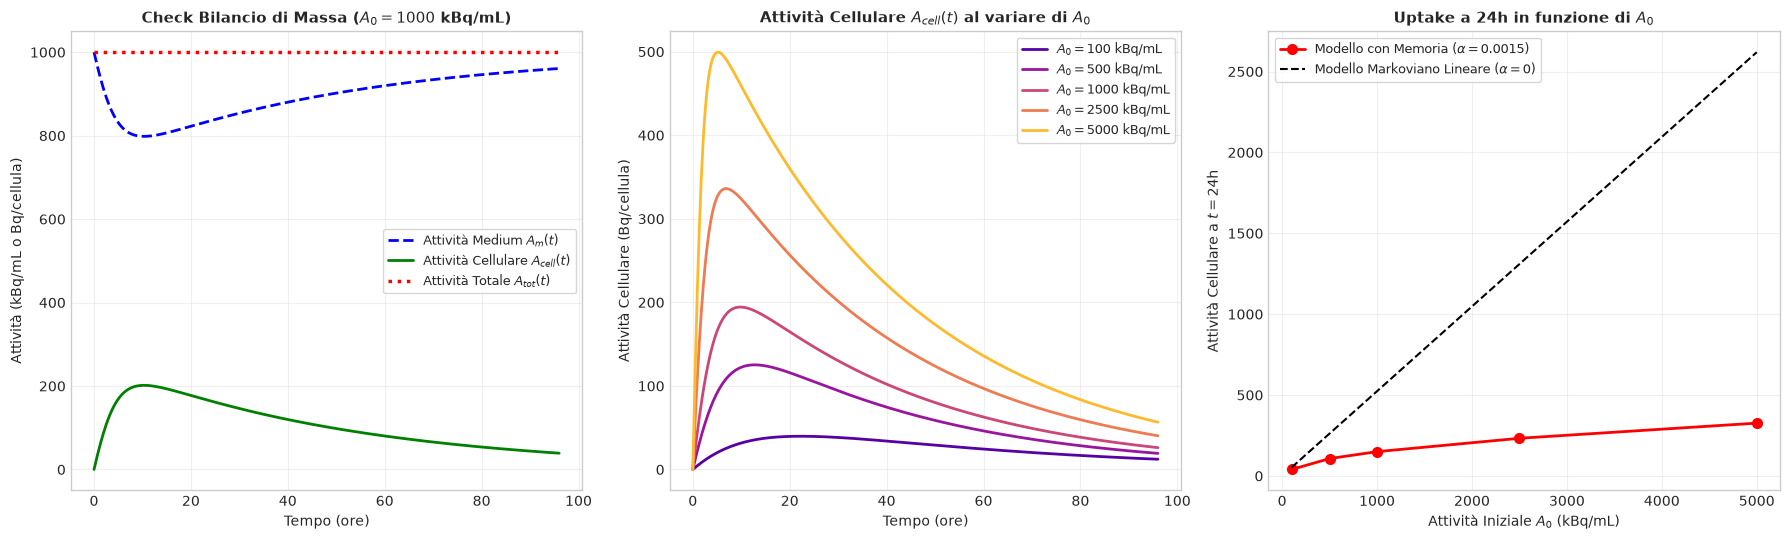

In [5]:
# =============================================================================
# 3. CHECK BILANCIO DI MASSA, SCALING SU A0 ED EFFETTO NON-LINEARE
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Parametri di riferimento per questa analisi
alpha_ref = 0.0015   # Costante di danno di riferimento
A0_list = [100.0, 500.0, 1000.0, 2500.0, 5000.0]

# -----------------------------------------------------------------------------
# Panel A: Check del Bilancio di Massa (lambda = 0 per dati decay-corrected)
# -----------------------------------------------------------------------------
lmbda_check = 0.0
A0_check = 1000.0

sol_check = solve_ivp(
    radionuclide_memory_ode, 
    t_span, 
    [A0_check, 0.0, 1.0], 
    args=(kin, kout, alpha_ref, gamma, lmbda_check), 
    t_eval=t_eval
)

Am_check    = sol_check.y[0]
Acell_check = sol_check.y[1]
Atot_check  = Am_check + Acell_check

axes[0].plot(sol_check.t, Am_check, 'b--', linewidth=2, label=r'Attività Medium $A_m(t)$')
axes[0].plot(sol_check.t, Acell_check, 'g-', linewidth=2, label=r'Attività Cellulare $A_{cell}(t)$')
axes[0].plot(sol_check.t, Atot_check, 'r:', linewidth=2.5, label=r'Attività Totale $A_{tot}(t)$')

axes[0].set_title(f'Check Bilancio di Massa ($A_0 = {A0_check:.0f}$ kBq/mL)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Tempo (ore)', fontsize=10)
axes[0].set_ylabel('Attività (kBq/mL o Bq/cellula)', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True, fontsize=9)

# -----------------------------------------------------------------------------
# Panel B: Studio di Acell(t) al variare di A0 (con lmbda di Lu-177)
# -----------------------------------------------------------------------------
lmbda_lu177 = 0.00435
colors_plasma = plt.cm.plasma(np.linspace(0.15, 0.85, len(A0_list)))
Acell_at_24h = []

for idx, A0_val in enumerate(A0_list):
    sol = solve_ivp(
        radionuclide_memory_ode, 
        t_span, 
        [A0_val, 0.0, 1.0], 
        args=(kin, kout, alpha_ref, gamma, lmbda_lu177), 
        t_eval=t_eval
    )
    Acell_t = sol.y[1]
    axes[1].plot(sol.t, Acell_t, linewidth=2, color=colors_plasma[idx], label=f'$A_0 = {A0_val:.0f}$ kBq/mL')
    
    # Estrazione accumulo a t = 24h
    idx_24h = np.argmin(np.abs(sol.t - 24.0))
    Acell_at_24h.append(Acell_t[idx_24h])

axes[1].set_title(r'Attività Cellulare $A_{cell}(t)$ al variare di $A_0$', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Tempo (ore)', fontsize=10)
axes[1].set_ylabel('Attività Cellulare (Bq/cellula)', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=True, fontsize=9)

# -----------------------------------------------------------------------------
# Panel C: Curva Dose-Risposta a t = 24h (Memoria vs Markoviano)
# -----------------------------------------------------------------------------
Acell_no_mem_24h = []
for A0_val in A0_list:
    sol_no_mem = solve_ivp(
        radionuclide_memory_ode, 
        t_span, 
        [A0_val, 0.0, 1.0], 
        args=(kin, kout, 0.0, 0.0, lmbda_lu177), 
        t_eval=t_eval
    )
    idx_24h = np.argmin(np.abs(sol_no_mem.t - 24.0))
    Acell_no_mem_24h.append(sol_no_mem.y[1][idx_24h])

axes[2].plot(A0_list, Acell_at_24h, 'ro-', linewidth=2, markersize=7, label=r'Modello con Memoria ($\alpha = 0.0015$)')
axes[2].plot(A0_list, Acell_no_mem_24h, 'k--', linewidth=1.5, label=r'Modello Markoviano Lineare ($\alpha = 0$)')

axes[2].set_title(r'Uptake a 24h in funzione di $A_0$', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Attività Iniziale $A_0$ (kBq/mL)', fontsize=10)
axes[2].set_ylabel(r'Attività Cellulare a $t=24\text{h}$', fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

<>:151: SyntaxWarning: invalid escape sequence '\s'
<>:151: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_522045/2670883106.py:151: SyntaxWarning: invalid escape sequence '\s'
  axes[2].set_ylabel('Residuo Normalizzato $(\sigma)$', fontsize=11)


PARAMETRO  | VALORE STIMATO  | INCERTEZZA (±σ)   | ERR %    | UNITÀ
k_in       | 3.705947e-04    | 4.504679e-05      | 12.16  % | h^-1
k_out      | 6.622689e-02    | 2.746823e-02      | 41.48  % | h^-1
alpha      | 2.735081e-01    | 1.313278e-01      | 48.02  % | (Bq/cell)^-1 h^-1
gamma      | 2.144280e-02    | 7.710405e-03      | 35.96  % | h^-1
---------------------------------------------------------------------------
Chi-quadro ponderato (SSQ) : 1.1744
Gradi di Libertà (DoF)     : 5
Chi-quadro ridotto (MSE)   : 0.2349


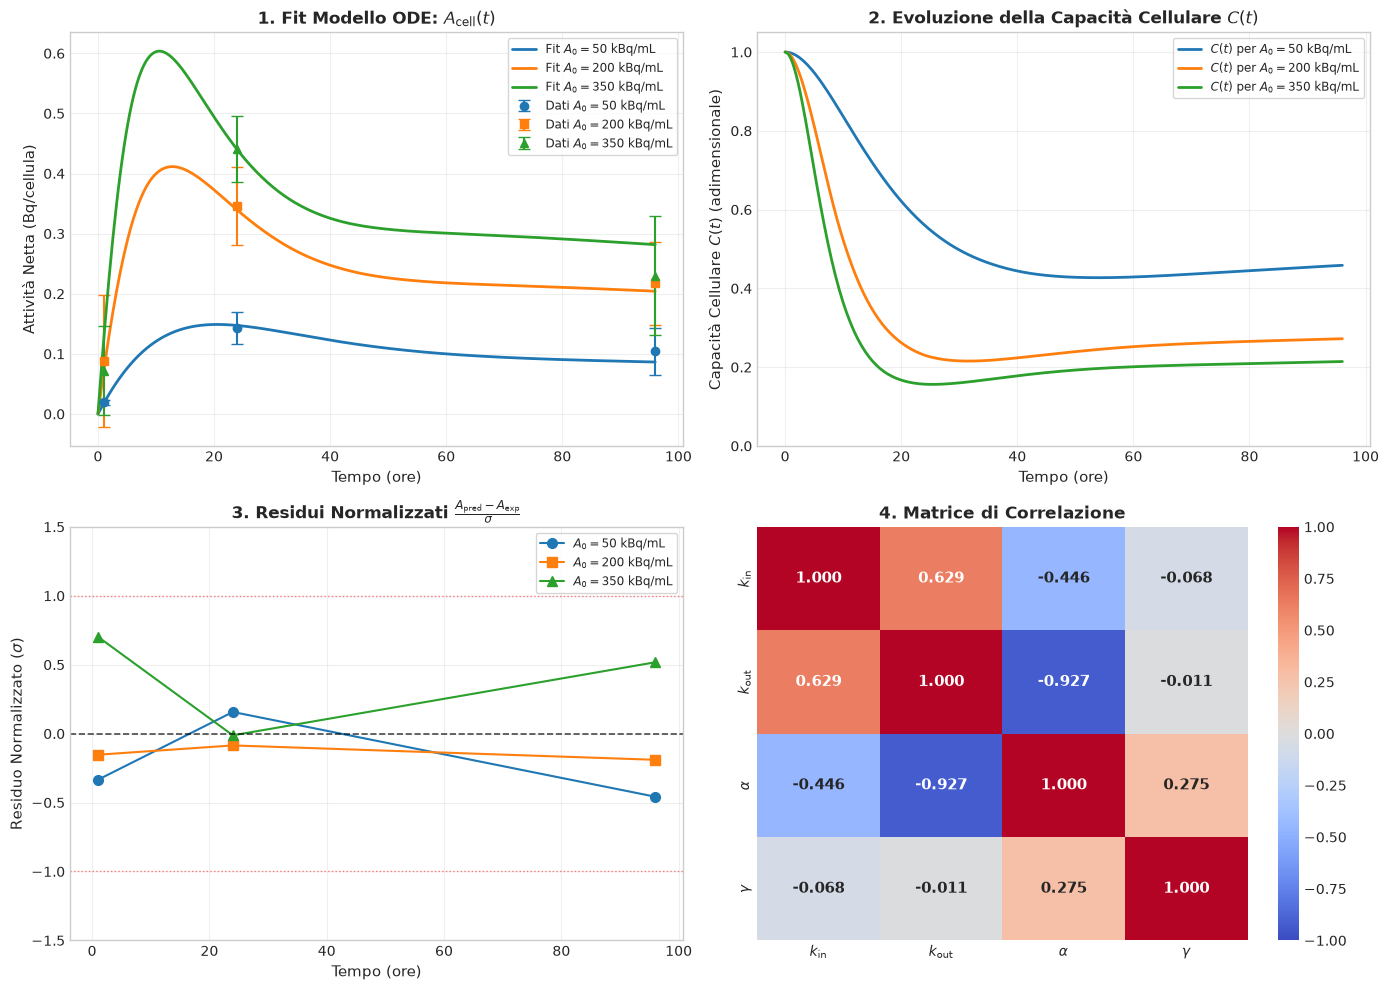

In [ ]:
# =============================================================================
# 1. DATI SPERIMENTALI E PARAMETRI FISICI (Ag-111)
# =============================================================================
t_exp = np.array([1.0, 24.0, 96.0])
A0_exp = np.array([50.0, 200.0, 350.0])
bg = np.array([0.004199309, 0.003368672, 0.000942459])

A_int_raw = np.array([
    [0.023594163, 0.146368766, 0.105341900],  # A0 = 50 kBq/mL
    [0.092211399, 0.349493079, 0.218233662],  # A0 = 200 kBq/mL
    [0.076153440, 0.443769956, 0.231148121]   # A0 = 350 kBq/mL
])

err_matrix = np.array([
    [0.004641692, 0.026652162, 0.039304734],
    [0.109901502, 0.064321945, 0.068945026],
    [0.074465535, 0.055049521, 0.099395703]
])

A_int_net = np.maximum(A_int_raw - bg, 1e-6)

# Ag-111: T_half = 7.45 giorni = 178.8 ore
T_half = 7.45 * 24.0
lmbda = np.log(2) / T_half

# =============================================================================
# 2. MODELLO ODE E DEFINIZIONE FIT
# =============================================================================
def radionuclide_memory_ode(t, y, kin, kout, alpha, gamma, lmbda):
    Am, Acell, C = y
    dAm    = - lmbda * Am - kin * C * Am + kout * Acell
    dAcell = - lmbda * Acell + kin * C * Am - kout * Acell
    dC     = - alpha * C * Acell + gamma * (1.0 - C)
    return [dAm, dAcell, dC]

def predict_Acell(params, t_exp, A0_exp, lmbda):
    kin, kout, alpha, gamma = params
    t_span = (0, max(t_exp))
    pred_matrix = np.zeros((len(A0_exp), len(t_exp)))
    
    for i, A0 in enumerate(A0_exp):
        sol = solve_ivp(
            radionuclide_memory_ode,
            t_span,
            [A0, 0.0, 1.0],
            args=(kin, kout, alpha, gamma, lmbda),
            t_eval=t_exp,
            method='RK45',
            rtol=1e-6,
            atol=1e-8
        )
        pred_matrix[i, :] = sol.y[1]
    return pred_matrix

def residuals(params, t_exp, A0_exp, A_int_net, err_matrix, lmbda):
    pred = predict_Acell(params, t_exp, A0_exp, lmbda)
    return ((pred - A_int_net) / err_matrix).ravel()

# Fit dei 4 parametri
x0 = [0.001, 0.05, 0.1, 0.05]
bounds = ([1e-6, 1e-6, 0.0, 1e-6], [1.0, 1.0, 10.0, 1.0])

res_fit = least_squares(residuals, x0, bounds=bounds, args=(t_exp, A0_exp, A_int_net, err_matrix, lmbda))

# =============================================================================
# 3. CALCOLO COVARIANZA, ERRORI E STATISTICHE
# =============================================================================
J = res_fit.jac
ssq = 2 * res_fit.cost
dof = len(A_int_net.ravel()) - len(x0)
mse = ssq / dof

cov = np.linalg.inv(J.T @ J) * mse
perr = np.sqrt(np.diag(cov))
rel_err = (perr / res_fit.x) * 100
corr_matrix = cov / np.outer(perr, perr)

# Residui Normalizzati
pred = predict_Acell(res_fit.x, t_exp, A0_exp, lmbda)
res_norm = (pred - A_int_net) / err_matrix

# =============================================================================
# 4. STAMPA DEI RISULTATI A CONSOLE
# =============================================================================
p_labels = ['k_in', 'k_out', 'alpha', 'gamma']
units = ['h^-1', 'h^-1', '(Bq/cell)^-1 h^-1', 'h^-1']

print("=" * 75)
print(f"{'PARAMETRO':<10} | {'VALORE STIMATO':<15} | {'INCERTEZZA (±σ)':<17} | {'ERR %':<8} | {'UNITÀ'}")
print("=" * 75)
for name, val, err, rel, unit in zip(p_labels, res_fit.x, perr, rel_err, units):
    print(f"{name:<10} | {val:<15.6e} | {err:<17.6e} | {rel:<7.2f}% | {unit}")
print("-" * 75)
print(f"Chi-quadro ponderato (SSQ) : {ssq:.4f}")
print(f"Gradi di Libertà (DoF)     : {dof}")
print(f"Chi-quadro ridotto (MSE)   : {mse:.4f}")
print("=" * 75)

# =============================================================================
# 5. GRAFICO COMPLETO (4 PANNELLI: 2x2)
# =============================================================================
t_dense = np.linspace(0, 96, 300)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']
p_names = [r'$k_{\mathrm{in}}$', r'$k_{\mathrm{out}}$', r'$\alpha$', r'$\gamma$']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# --- PANNELLO 1: FIT DELL'ATTIVITÀ INTRACELLULARE ---
for i, A0 in enumerate(A0_exp):
    sol = solve_ivp(
        radionuclide_memory_ode,
        (0, 96),
        [A0, 0.0, 1.0],
        args=(res_fit.x[0], res_fit.x[1], res_fit.x[2], res_fit.x[3], lmbda),
        t_eval=t_dense,
        method='RK45'
    )
    axes[0].errorbar(t_exp, A_int_net[i, :], yerr=err_matrix[i, :], fmt=markers[i], color=colors[i],
                     capsize=4, elinewidth=1.5, markersize=6, label=f'Dati $A_0 = {A0:.0f}$ kBq/mL')
    axes[0].plot(sol.t, sol.y[1], '-', color=colors[i], linewidth=2, label=f'Fit $A_0 = {A0:.0f}$ kBq/mL')
    
    # --- PANNELLO 2: EVOLUZIONE DI C(t) ---
    axes[1].plot(sol.t, sol.y[2], '-', color=colors[i], linewidth=2, label=f'$C(t)$ per $A_0 = {A0:.0f}$ kBq/mL')

axes[0].set_title(r'1. Fit Modello ODE: $A_{\mathrm{cell}}(t)$', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività Netta (Bq/cellula)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True, fontsize=8.5)

axes[1].set_title(r'2. Evoluzione della Capacità Cellulare $C(t)$', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tempo (ore)', fontsize=11)
axes[1].set_ylabel('Capacità Cellulare $C(t)$ (adimensionale)', fontsize=11)
axes[1].set_ylim([0, 1.05])
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=True, fontsize=8.5)

# --- PANNELLO 3: RESIDUI NORMALIZZATI ---
for i, A0 in enumerate(A0_exp):
    axes[2].plot(t_exp, res_norm[i, :], marker=markers[i], color=colors[i],
                 linestyle='-', linewidth=1.5, markersize=7, label=f'$A_0 = {A0:.0f}$ kBq/mL')

axes[2].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
axes[2].axhline(1, color='red', linestyle=':', linewidth=1.0, alpha=0.5)
axes[2].axhline(-1, color='red', linestyle=':', linewidth=1.0, alpha=0.5)

axes[2].set_title(r'3. Residui Normalizzati $\frac{A_{\mathrm{pred}} - A_{\mathrm{exp}}}{\sigma}$', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tempo (ore)', fontsize=11)
axes[2].set_ylabel('Residuo Normalizzato $(\sigma)$', fontsize=11)
axes[2].set_ylim([-1.5, 1.5])
axes[2].grid(True, alpha=0.3)
axes[2].legend(frameon=True, fontsize=8.5)

# --- PANNELLO 4: MATRICE DI CORRELAZIONE ---
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=p_names, yticklabels=p_names, ax=axes[3], cbar=True,
            annot_kws={"size": 11, "weight": "bold"})

axes[3].set_title('4. Matrice di Correlazione', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Parametri fisici del radionuclide e del fit

kin   = 3.705947e-04
kout  = 6.622688e-02
alpha = 2.735081e-01
gamma = 2.144280e-02

# 2. Nuovi valori di attività iniziale in terreno (kBq/mL)
A0_vals = [59.7, 119.0, 239.0, 478.0]
t_4d = 96.0   # 4 giorni in ore

# Sistema ODE con equazione aggiuntiva per l'attività cumulata d(CumA)/dt = Acell
def ode_system_cum(t, y):
    Am, Acell, C, CumA = y
    dAm    = - lmbda * Am - kin * C * Am + kout * Acell
    dAcell = - lmbda * Acell + kin * C * Am - kout * Acell
    dC     = - alpha * C * Acell + gamma * (1.0 - C)
    dCumA  = Acell  # Integrale temporale dell'attività cellulare
    return [dAm, dAcell, dC, dCumA]

# 3. Calcolo dell'integrale
print("=" * 85)
print(f"{'A0 (kBq/mL)':<12} | {'Cum @ 4d (Bq·h/cell)':<22}")
print("=" * 85)

for A0 in A0_vals:
    # Integrazione fino a 6 giorni (144 h)
    sol = solve_ivp(
        ode_system_cum,
        (0, t_6d),
        [A0, 0.0, 1.0, 0.0],
        t_eval=[t_4d, t_6d],
        method='RK45',
        rtol=1e-8,
        atol=1e-10
    )
    
    cum_4d = sol.y[3][0]
    
    print(f"{A0:<12.2f} | {cum_4d:<22.4f}")

print("=" * 85)